In [3]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = r"E:\Analytic Plan BI\LinkedIn Dataset\linkedin_job_postings.csv"

jobs = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Rows:", len(jobs))
print("Columns:", len(jobs.columns))

print("\nColumn names:")
print(jobs.columns.tolist())

Dataset loaded successfully.
Rows: 1348454
Columns: 14

Column names:
['job_link', 'last_processed_time', 'got_summary', 'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location', 'first_seen', 'search_city', 'search_country', 'search_position', 'job_level', 'job_type']


In [4]:
print(jobs["first_seen"].head())
print("\nMissing first_seen:", jobs["first_seen"].isna().sum())

0    2024-01-15
1    2024-01-14
2    2024-01-14
3    2024-01-16
4    2024-01-17
Name: first_seen, dtype: object

Missing first_seen: 0


In [5]:
# Convert first_seen to datetime
jobs["first_seen"] = pd.to_datetime(
    jobs["first_seen"],
    errors="coerce"
)

# Count advertisements for each first-seen date
first_seen_counts = (
    jobs["first_seen"]
    .dt.date
    .value_counts()
    .sort_index()
)

print("FIRST-SEEN DISTRIBUTION")
print("=" * 40)
print(first_seen_counts)

print("\nSUMMARY")
print("=" * 40)
print(f"Total advertisements: {len(jobs):,}")
print(f"Valid first_seen values: {jobs['first_seen'].notna().sum():,}")
print(f"Missing first_seen values: {jobs['first_seen'].isna().sum():,}")
print(f"Earliest first_seen: {jobs['first_seen'].min()}")
print(f"Latest first_seen: {jobs['first_seen'].max()}")

FIRST-SEEN DISTRIBUTION
first_seen
2024-01-12    206197
2024-01-13    404057
2024-01-14    460035
2024-01-15     85079
2024-01-16    157058
2024-01-17     36028
Name: count, dtype: int64

SUMMARY
Total advertisements: 1,348,454
Valid first_seen values: 1,348,454
Missing first_seen values: 0
Earliest first_seen: 2024-01-12 00:00:00
Latest first_seen: 2024-01-17 00:00:00


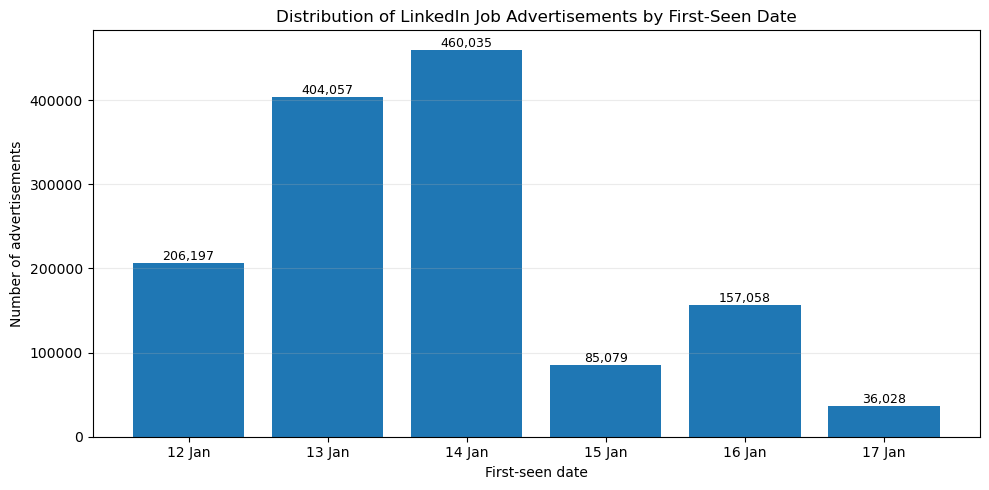

In [6]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    [pd.Timestamp(d).strftime("%d %b") for d in first_seen_counts.index],
    first_seen_counts.values
)

# Add advertisement counts above each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xlabel("First-seen date")
plt.ylabel("Number of advertisements")
plt.title("Distribution of LinkedIn Job Advertisements by First-Seen Date")

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

BA advertisements: 4,576

BA first-seen distribution:
first_seen
2024-01-12     107
2024-01-13    2950
2024-01-14     756
2024-01-15      95
2024-01-16     628
2024-01-17      40
Name: count, dtype: int64

Earliest: 2024-01-12 00:00:00
Latest: 2024-01-17 00:00:00


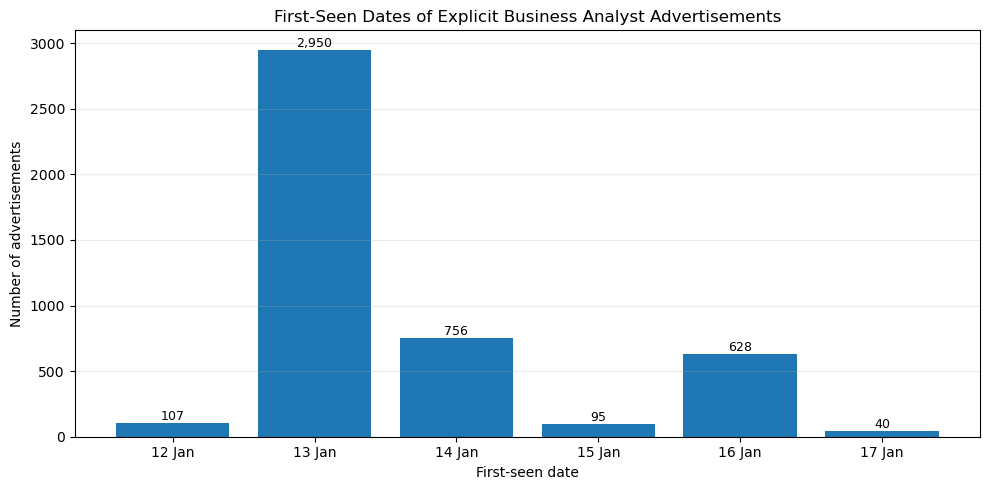

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the final explicit-title BA population
ba_jobs = pd.read_csv(
    r"E:\Analytic Plan BI\LinkedIn Dataset\business_analyst_jobs.csv"
)

print(f"BA advertisements: {len(ba_jobs):,}")

# Convert first_seen to datetime
ba_jobs["first_seen"] = pd.to_datetime(
    ba_jobs["first_seen"],
    errors="coerce"
)

# Count advertisements by first-seen date
ba_first_seen = (
    ba_jobs["first_seen"]
    .dt.date
    .value_counts()
    .sort_index()
)

print("\nBA first-seen distribution:")
print(ba_first_seen)

print("\nEarliest:", ba_jobs["first_seen"].min())
print("Latest:", ba_jobs["first_seen"].max())

# Plot
plt.figure(figsize=(10, 5))

bars = plt.bar(
    [pd.Timestamp(d).strftime("%d %b") for d in ba_first_seen.index],
    ba_first_seen.values
)

# Add counts above bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xlabel("First-seen date")
plt.ylabel("Number of advertisements")
plt.title("First-Seen Dates of Explicit Business Analyst Advertisements")

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()